# Intraday Position - Analytics

## Import Library

In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
from utils import load_analytics_dataset, show_3_distribution_charts, show_3_sns_charts

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')

## Load Price Data

In [2]:
%%time
dataset = load_analytics_dataset()

CPU times: user 13.8 s, sys: 833 ms, total: 14.7 s
Wall time: 29.7 s


## Charts

In [11]:
data = dataset[(dataset.index > '2020-11-01 00:00:00') & (dataset.index < '2025-05-30 00:00:00')].copy()

In [12]:
data['intraday_position'] = data['intraday_position'].fillna('NaN')

In [19]:
data['intraday_position'].unique()

<ArrowStringArray>
['norm', 'valley', 'peak']
Length: 3, dtype: str

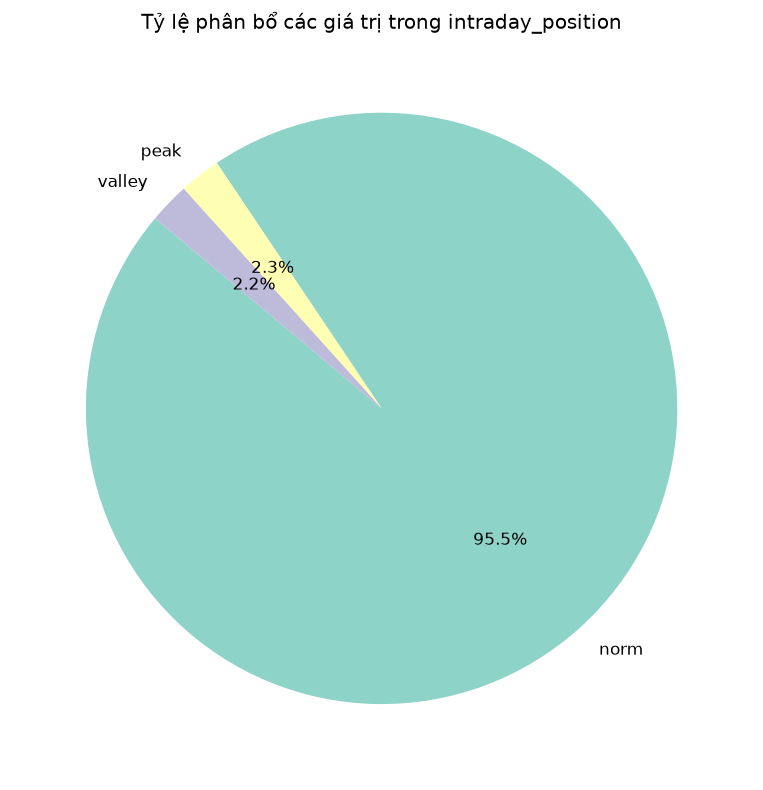

In [20]:
# 1. Đếm số lần xuất hiện của từng giá trị trong intraday_position
counts = data['intraday_position'].value_counts(dropna=False)

# 2. Vẽ biểu đồ tròn
plt.figure(figsize=(8, 8))
plt.pie(
    counts.values, 
    labels=counts.index, 
    autopct='%1.1f%%',  # Hiển thị tỷ lệ phần trăm (1 chữ số thập phân)
    startangle=140,     # Góc xoay biểu đồ
    colors=plt.cm.Set3.colors # Bộ màu hài hòa
)

plt.title('Tỷ lệ phân bổ các giá trị trong intraday_position')
plt.show()

In [13]:
import seaborn as sns

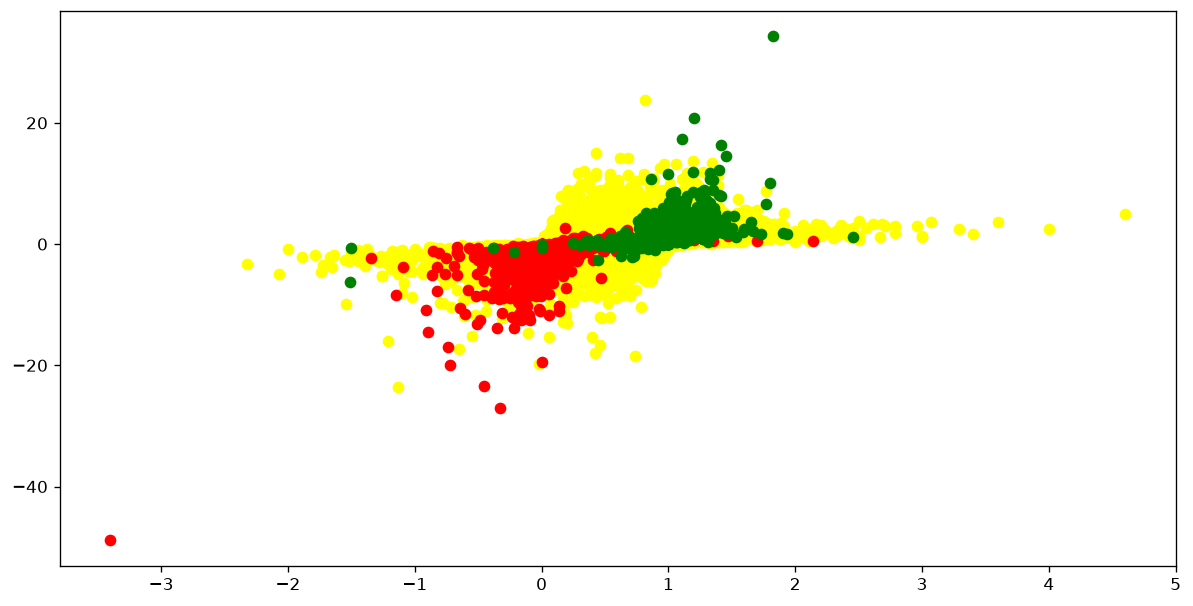

In [22]:
data_norm = data[data['intraday_position'] == "norm"]
data_valley = data[data['intraday_position'] == "valley"]
data_peak = data[data['intraday_position'] == "peak"]
plt.scatter(data_norm['close_vs_session_range'], data_norm['dm'], c='yellow')
plt.scatter(data_valley['close_vs_session_range'], data_valley['dm'], c='red')
plt.scatter(data_peak['close_vs_session_range'], data_peak['dm'], c='green')

Text(0.5, 1.0, 'Sự ảnh hưởng của close_vs_session_range and dm tới intraday_position deal hôm sau')

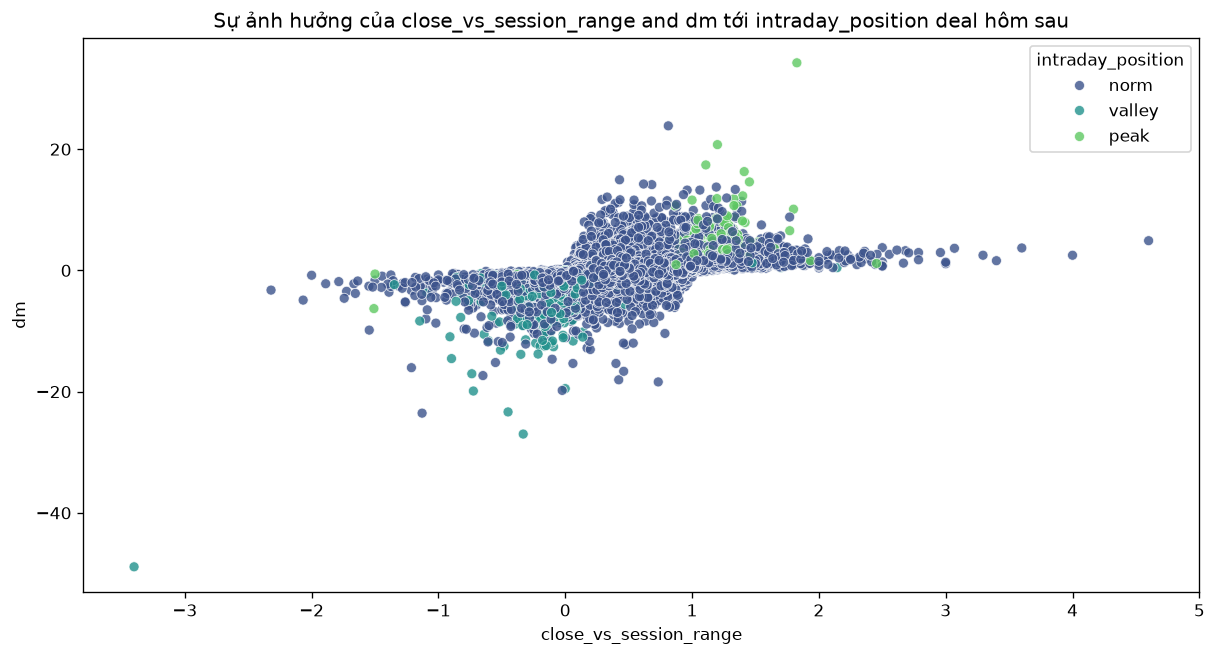

In [24]:
sns.scatterplot(
    data=data[['close_vs_session_range', 'dm', 'intraday_position']],
    x='close_vs_session_range',
    y='dm',
    hue='intraday_position',
    palette='viridis',
    alpha=0.8
)
plt.title('Sự ảnh hưởng của close_vs_session_range and dm tới intraday_position deal hôm sau')